In [4]:
import os
RESULTS_DIR = "../results"
print(os.path.exists(f"{RESULTS_DIR}/qwen2vl_2b_tuningA.csv"))
print(os.path.exists(f"{RESULTS_DIR}/qwen2vl_2b_tuningB.csv"))

True
True


### 01 - Imports

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from PIL import Image

RESULTS_DIR = "../results"
DATA_DIR    = "../data"
AI2D_DIR    = "../ai2d"

BASE_ACC    = 69.25
TUNING_A_ACC = 71.46
TUNING_B_ACC = 88.71

os.makedirs(f"{RESULTS_DIR}/figures", exist_ok=True)
print("✓ Ready")

✓ Ready


### 02 - Load Prediction Files

In [6]:
df_A = pd.read_csv(f"{RESULTS_DIR}/qwen2vl_2b_tuningA.csv")
df_B = pd.read_csv(f"{RESULTS_DIR}/qwen2vl_2b_tuningB.csv")

# Add condition column
df_A["condition"] = "Tuning A"
df_B["condition"] = "Tuning B"

print(f"Tuning A predictions: {len(df_A)}")
print(f"Tuning B predictions: {len(df_B)}")
print(f"\nColumns: {df_A.columns.tolist()}")

Tuning A predictions: 2330
Tuning B predictions: 2330

Columns: ['question_id', 'image_name', 'category', 'abc_label', 'raw_output', 'prediction', 'ground_truth', 'correct', 'condition']


### 03 - Overall accuracy comparison

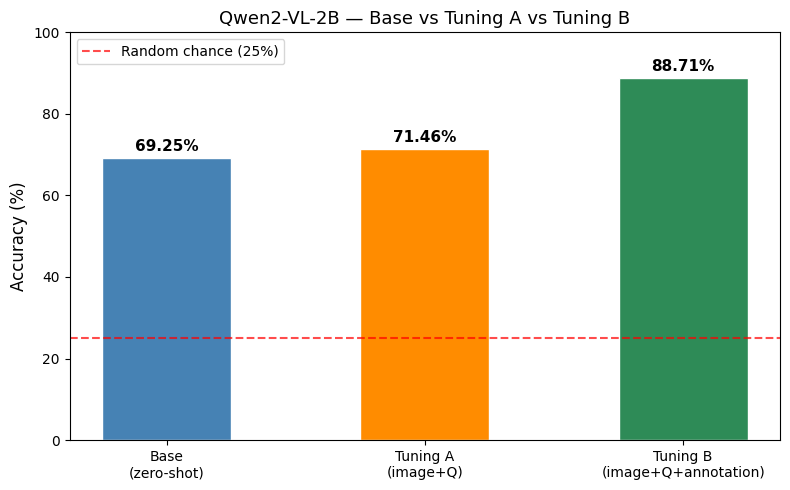

✓ Saved


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

conditions = ["Base\n(zero-shot)", "Tuning A\n(image+Q)", "Tuning B\n(image+Q+annotation)"]
accuracies = [BASE_ACC, TUNING_A_ACC, TUNING_B_ACC]
colors     = ["steelblue", "darkorange", "seagreen"]

bars = ax.bar(conditions, accuracies, color=colors, width=0.5, edgecolor="white")
ax.axhline(y=25,  color="red",  linestyle="--", alpha=0.7, label="Random chance (25%)")
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Qwen2-VL-2B — Base vs Tuning A vs Tuning B", fontsize=13)
ax.set_ylim(0, 100)
ax.legend()

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figures/01_overall_comparison.png", dpi=150)
plt.show()
print("✓ Saved")

### 04 - abcLabel vs Descriptive (key hypothesis)

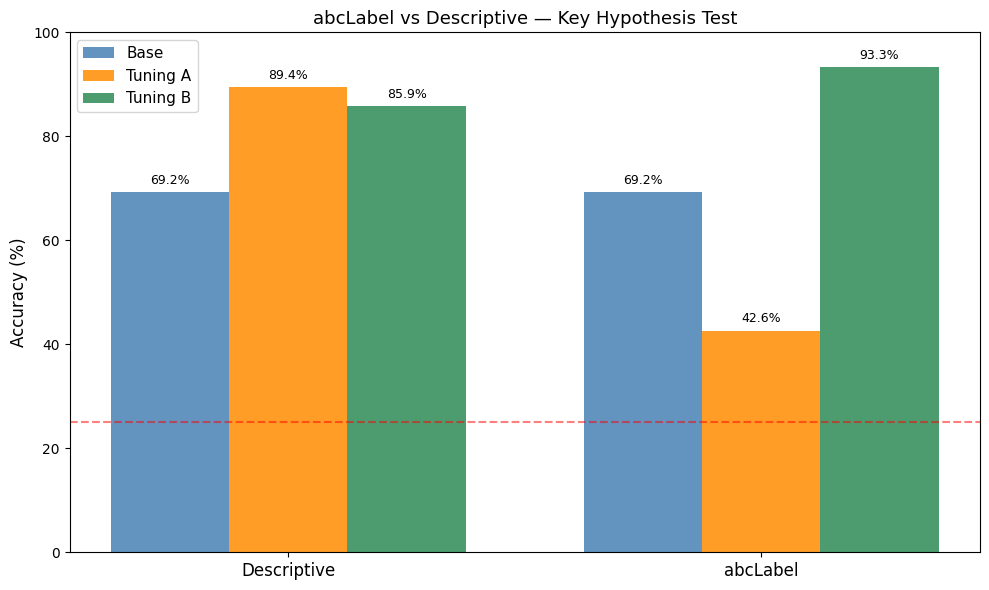


Key finding:
  abcLabel  — Tuning A: 42.6%  →  Tuning B: 93.3%  (Δ = +50.7%)
  Descriptive — Tuning A: 89.4%  →  Tuning B: 85.9%  (Δ = -3.6%)

✓ Hypothesis confirmed: Tuning B improves abcLabel far more than Descriptive


In [8]:
# Compute for both conditions
abc_A = df_A.groupby("abc_label")["correct"].mean() * 100
abc_B = df_B.groupby("abc_label")["correct"].mean() * 100

abc_A.index = abc_A.index.map({True: "abcLabel", False: "Descriptive"})
abc_B.index = abc_B.index.map({True: "abcLabel", False: "Descriptive"})

# Add base estimates (from zero-shot eval — approximate)
labels    = ["Descriptive", "abcLabel"]
base_vals = [BASE_ACC, BASE_ACC]  # base didn't differentiate
a_vals    = [abc_A["Descriptive"], abc_A["abcLabel"]]
b_vals    = [abc_B["Descriptive"], abc_B["abcLabel"]]

x     = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width,   base_vals, width, label="Base",     color="steelblue",  alpha=0.85)
b2 = ax.bar(x,           a_vals,    width, label="Tuning A", color="darkorange", alpha=0.85)
b3 = ax.bar(x + width,   b_vals,    width, label="Tuning B", color="seagreen",   alpha=0.85)

ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("abcLabel vs Descriptive — Key Hypothesis Test", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.axhline(y=25, color="red", linestyle="--", alpha=0.5, label="Random (25%)")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figures/02_abclabel_hypothesis.png", dpi=150)
plt.show()

print("\nKey finding:")
print(f"  abcLabel  — Tuning A: {abc_A['abcLabel']:.1f}%  →  Tuning B: {abc_B['abcLabel']:.1f}%  (Δ = {abc_B['abcLabel']-abc_A['abcLabel']:+.1f}%)")
print(f"  Descriptive — Tuning A: {abc_A['Descriptive']:.1f}%  →  Tuning B: {abc_B['Descriptive']:.1f}%  (Δ = {abc_B['Descriptive']-abc_A['Descriptive']:+.1f}%)")
print("\n✓ Hypothesis confirmed: Tuning B improves abcLabel far more than Descriptive")

### 05 - Per category heatmap

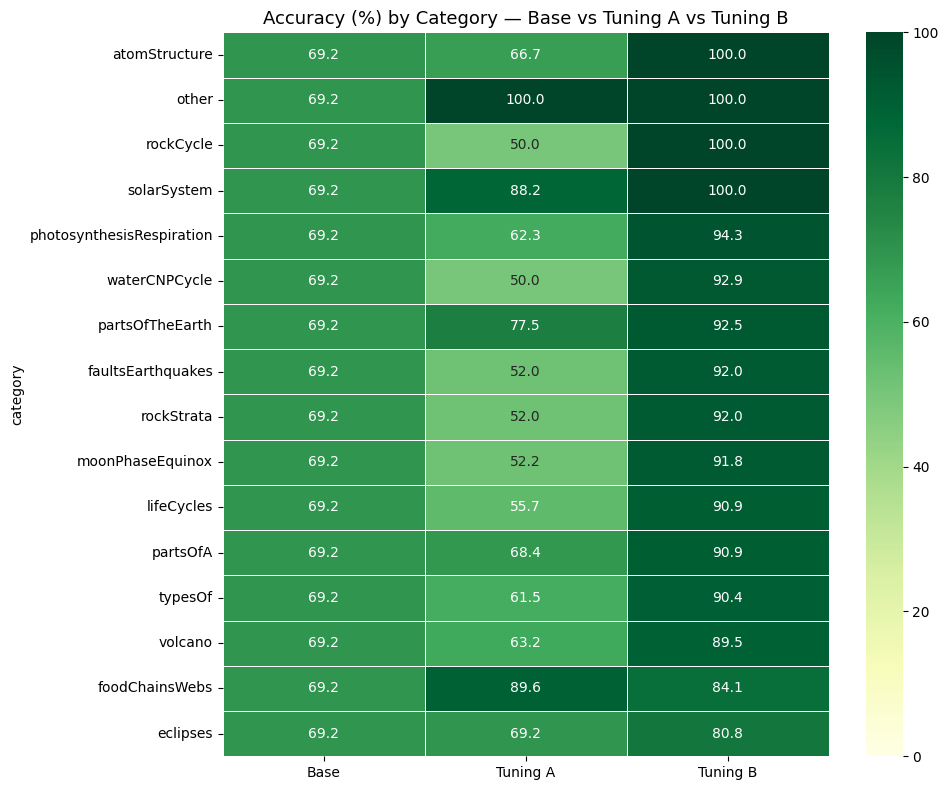

✓ Saved


In [9]:
cat_A = df_A.groupby("category")["correct"].mean() * 100
cat_B = df_B.groupby("category")["correct"].mean() * 100

cat_df = pd.DataFrame({
    "Base":     BASE_ACC,
    "Tuning A": cat_A,
    "Tuning B": cat_B,
}).round(1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cat_df.sort_values("Tuning B", ascending=False),
    annot=True, fmt=".1f", cmap="YlGn",
    linewidths=0.5, ax=ax,
    vmin=0, vmax=100
)
ax.set_title("Accuracy (%) by Category — Base vs Tuning A vs Tuning B", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figures/03_category_heatmap.png", dpi=150)
plt.show()
print("✓ Saved")

### 06 - Per category bar chart (Tuning B)

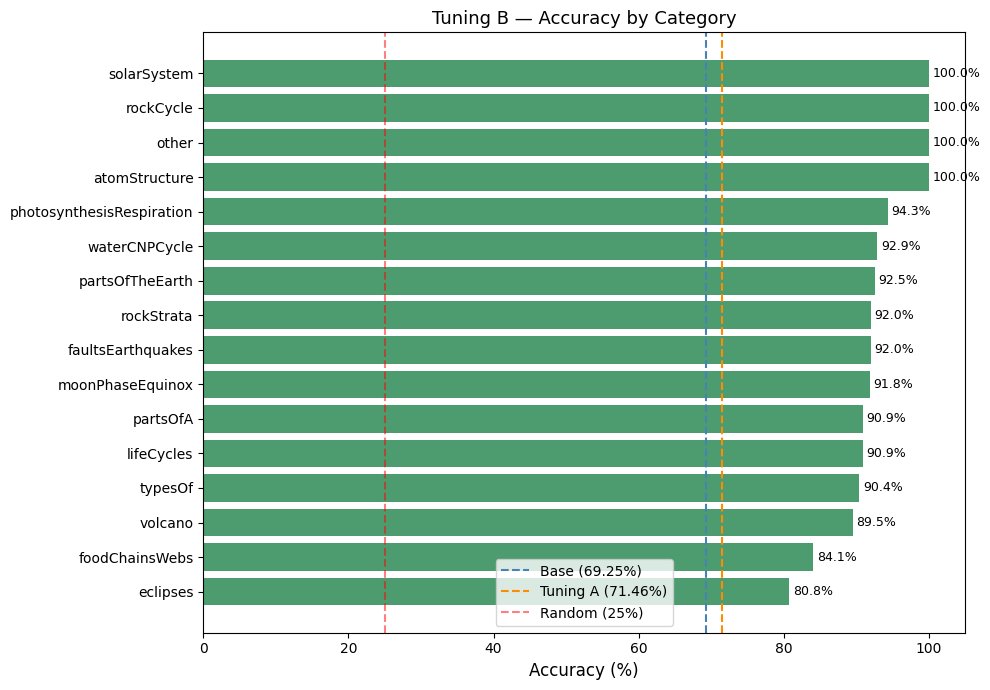

✓ Saved


In [10]:
cat_B_sorted = cat_B.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(cat_B_sorted.index, cat_B_sorted.values, color="seagreen", alpha=0.85)
ax.axvline(x=BASE_ACC,    color="steelblue",  linestyle="--", label=f"Base ({BASE_ACC}%)")
ax.axvline(x=TUNING_A_ACC, color="darkorange", linestyle="--", label=f"Tuning A ({TUNING_A_ACC}%)")
ax.axvline(x=25,           color="red",        linestyle="--", alpha=0.5, label="Random (25%)")
ax.set_xlabel("Accuracy (%)", fontsize=12)
ax.set_title("Tuning B — Accuracy by Category", fontsize=13)
ax.legend(fontsize=10)

for bar, val in zip(bars, cat_B_sorted.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figures/04_category_tuningB.png", dpi=150)
plt.show()
print("✓ Saved")

### 07 - Loss curves comparison

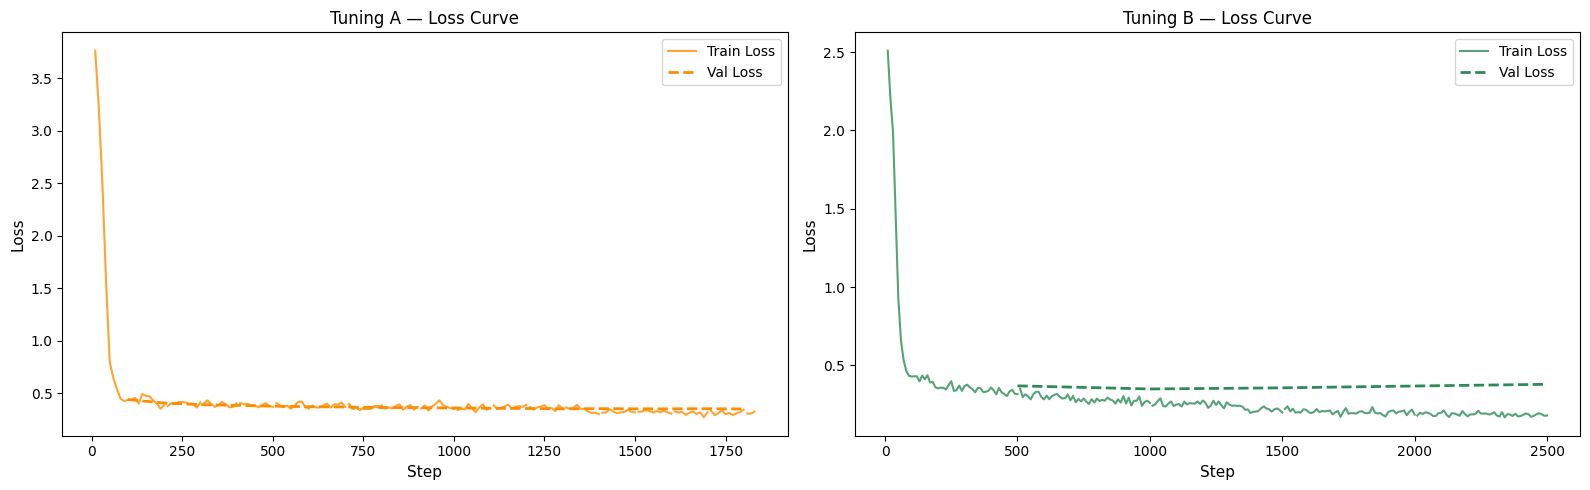

✓ Saved


In [11]:
log_A_path = "../logs/qwen2vl_2b_tuningA/training_log.csv"
log_B_path = "../logs/qwen2vl_2b_tuningB/training_log.csv"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (log_path, label, color) in enumerate([
    (log_A_path, "Tuning A", "darkorange"),
    (log_B_path, "Tuning B", "seagreen"),
]):
    if not os.path.exists(log_path):
        print(f"Log not found: {log_path}")
        continue

    log_df = pd.read_csv(log_path)

    if "loss" in log_df.columns:
        axes[i].plot(log_df["step"], log_df["loss"],
                     label="Train Loss", color=color, alpha=0.8)
    if "eval_loss" in log_df.columns:
        ev = log_df.dropna(subset=["eval_loss"])
        axes[i].plot(ev["step"], ev["eval_loss"],
                     label="Val Loss", color=color, linestyle="--", linewidth=2)

    axes[i].set_xlabel("Step", fontsize=11)
    axes[i].set_ylabel("Loss", fontsize=11)
    axes[i].set_title(f"{label} — Loss Curve", fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/figures/05_loss_curves.png", dpi=150)
plt.show()
print("✓ Saved")

### 08 - Summary table

In [12]:
summary = pd.DataFrame([
    {
        "Condition":    "Base (zero-shot)",
        "Overall Acc":  f"{BASE_ACC:.2f}%",
        "abcLabel Acc": "~69%",
        "Descriptive Acc": "~69%",
        "Notes": "No fine-tuning"
    },
    {
        "Condition":    "Tuning A (image+Q)",
        "Overall Acc":  f"{TUNING_A_ACC:.2f}%",
        "abcLabel Acc": f"{abc_A['abcLabel']:.2f}%",
        "Descriptive Acc": f"{abc_A['Descriptive']:.2f}%",
        "Notes": "Fine-tuned without annotation context"
    },
    {
        "Condition":    "Tuning B (image+Q+annotation)",
        "Overall Acc":  f"{TUNING_B_ACC:.2f}%",
        "abcLabel Acc": f"{abc_B['abcLabel']:.2f}%",
        "Descriptive Acc": f"{abc_B['Descriptive']:.2f}%",
        "Notes": "Fine-tuned with annotation context"
    },
])

print("="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

summary.to_csv(f"{RESULTS_DIR}/final_summary.csv", index=False)
print("✓ Saved to final_summary.csv")

FINAL RESULTS SUMMARY
                    Condition Overall Acc abcLabel Acc Descriptive Acc                                 Notes
             Base (zero-shot)      69.25%         ~69%            ~69%                        No fine-tuning
           Tuning A (image+Q)      71.46%       42.62%          89.42% Fine-tuned without annotation context
Tuning B (image+Q+annotation)      88.71%       93.29%          85.86%    Fine-tuned with annotation context
✓ Saved to final_summary.csv
